In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.utils import shuffle

In [59]:
df = pd.read_csv(r"C:\Users\rabab\Anaconda_Jupyter\Content\data.csv")
df.head()

,population,profit
0,5.5277,9.1302
1,8.5186,13.6620
2,7.0032,11.8540
3,5.8598,6.8233
4,8.3829,11.8860


In [60]:
# Step 2
data = shuffle(df)
x = data['population'].to_numpy().reshape((-1,1))
y = data['profit'].to_numpy().reshape((-1,1))

# Step 3 (manual splitting, or we can use train_test_split instead)
x_train = x[0:80]
y_train = y[0:80]
x_test = x[80:]
y_test = y[80:]

In [61]:
model = linear_model.LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Predict Function

In [70]:
def predict(data, intercept, slope):
    y_pred = []
    for x in data:
        y_pred.append(intercept + slope * x)
    return y_pred

## MSE Function

In [63]:
def mean_squared_error(y_actual, y_pred):
    size_y_actual = len(y_actual)
    MSE = 0
    
    for i in range(size_y_actual):
        MSE += (y_actual[i] - y_pred[i]) ** 2
        
    return MSE / size_y_actual

## TEST

In [64]:
# Step 5
y_pred = predict(x_test, -3.36, 1.16)
mse = mean_squared_error(y_test, y_pred)
print('Prediction: ' ,y_pred)
print('Mean squared error: %.2f'% mse)

Prediction:  [array([5.459596]), array([18.6162]), array([5.386632]), array([3.607192]), array([4.163992]), array([2.658544]), array([5.384776]), array([22.39548]), array([10.212]), array([2.912004]), array([5.14802]), array([6.877464]), array([3.285872]), array([3.369624]), array([6.521576]), array([9.35012])]
Mean squared error: 7.63


C:\Users\rabab\AppData\Local\Temp\ipykernel_18960\3024372844.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Mean squared error: %.2f'% mse)


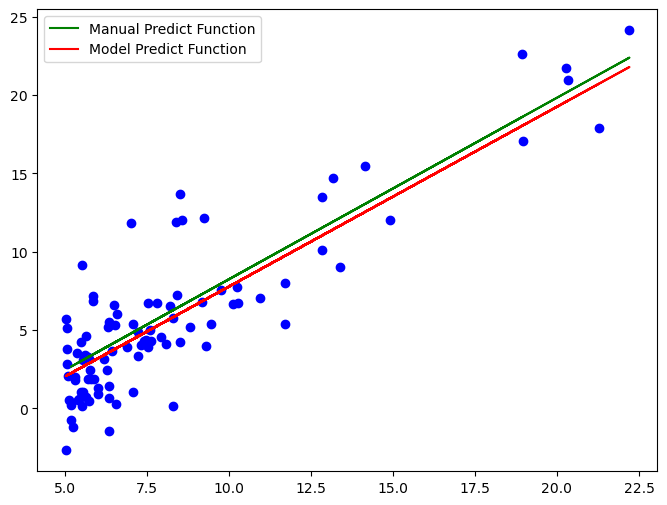

In [77]:
plt.figure(figsize=(8,6))
plt.scatter(x, y, color = 'blue')
plt.plot(x_test, y_pred, color='green',label="Manual Predict Function")
plt.plot(x, model.predict(x), color='red', label="Model Predict Function")
plt.legend()
plt.show()

In [66]:
sklearn_pred = model.predict(x_test)

from sklearn.metrics import mean_squared_error as sk_mse

print("Sklearn MSE:", sk_mse(y_test, sklearn_pred))
print(sklearn_pred)

Sklearn MSE: 7.722701114532242
[[ 5.0185074 ]
 [18.05199147]
 [ 4.9462262 ]
 [ 3.18343825]
 [ 3.7350277 ]
 [ 2.24366773]
 [ 4.94438756]
 [21.79590485]
 [ 9.72643825]
 [ 2.49475584]
 [ 4.70984713]
 [ 6.42310694]
 [ 2.86512518]
 [ 2.94809342]
 [ 6.07054935]
 [ 8.87262375]]


## Test on new Data

In [67]:
new_pop_data = pd.read_csv(r"C:\Users\rabab\Anaconda_Jupyter\Content\new_data.csv", names=['city','population'])
new_data = new_pop_data['population'].to_numpy().reshape(-1,1)
predictions = predict(new_data)

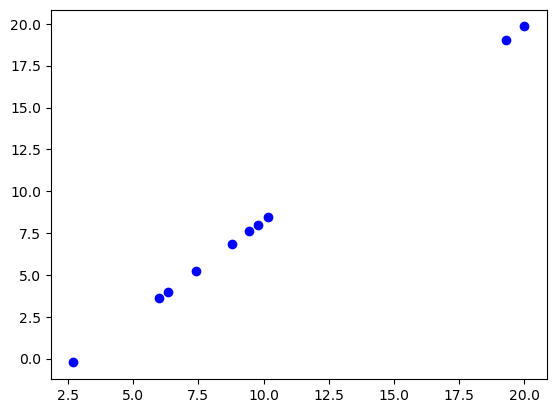

In [78]:
plt.scatter(new_pop_data['population'], predictions, color = 'b')

In [69]:
predictions

[array([7.602]),
 array([6.848]),
 array([-0.228]),
 array([19.84]),
 array([8.4604]),
 array([5.224]),
 array([3.6]),
 array([4.006]),
 array([8.008]),
 array([19.028])]